<a href="https://colab.research.google.com/github/AYMAN-CHAREF/machine-learning-et-deep-learning/blob/main/K_Means_Clustering_From_Scratch_in_Python_(Mathematical).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
import numpy as np

class KMeansClustering:
    def __init__(self, k=3):
        self.k = k
        self.centroids = None

    @staticmethod
    def euclidean_distance(data_point, centroids):
        return np.sqrt(np.sum((centroids - data_point)**2, axis=1))

    def fit(self, X, max_iterations=100):
        self.centroids = np.random.uniform(np.amin(X, axis=0), np.amax(X, axis=0),
                                          size=(self.k, X.shape[1]))

        for _ in range(max_iterations):
            y = []

            for data_point in X:
                distances = KMeansClustering.euclidean_distance(data_point, self.centroids)
                cluster_num = np.argmin(distances)
                y.append(cluster_num)
            y = np.array(y)

            cluster_indices = []

            for i in range(self.k):
                cluster_indices.append(np.argwhere(y==i))

            cluster_centers = []

            for i, indices in enumerate(cluster_indices):
                if len(indices) == 0:
                    cluster_centers.append(self.centroids[i])
                else:
                    cluster_centers.append(np.mean(X[indices], axis=0)[0])

            if np.max(self.centroids - np.array(cluster_centers)) < 0.0001:
                break
            else:
                self.centroids = np.array(cluster_centers)

        return y

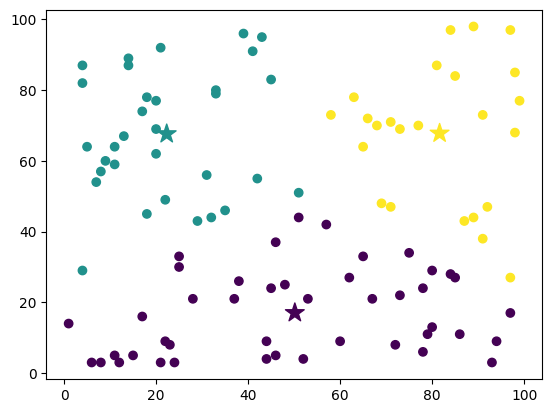

In [ ]:

random_points = np.random.randint(0, 100, (100, 2))


kmeans = KMeansClustering(k=3)
labels = kmeans.fit(random_points, max_iterations=100)


plt.scatter(random_points[:, 0], random_points[:, 1], c=labels)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
           c=range(len(kmeans.centroids)), marker='*', s=200)
plt.show()

For k=2	Avg. Sil. Coef: 0.3132	Distortion: 1.3868
For k=3	Avg. Sil. Coef: 0.4075	Distortion: 0.7704
For k=4	Avg. Sil. Coef: 0.3947	Distortion: 0.6536
For k=5	Avg. Sil. Coef: 0.4116	Distortion: 0.5520


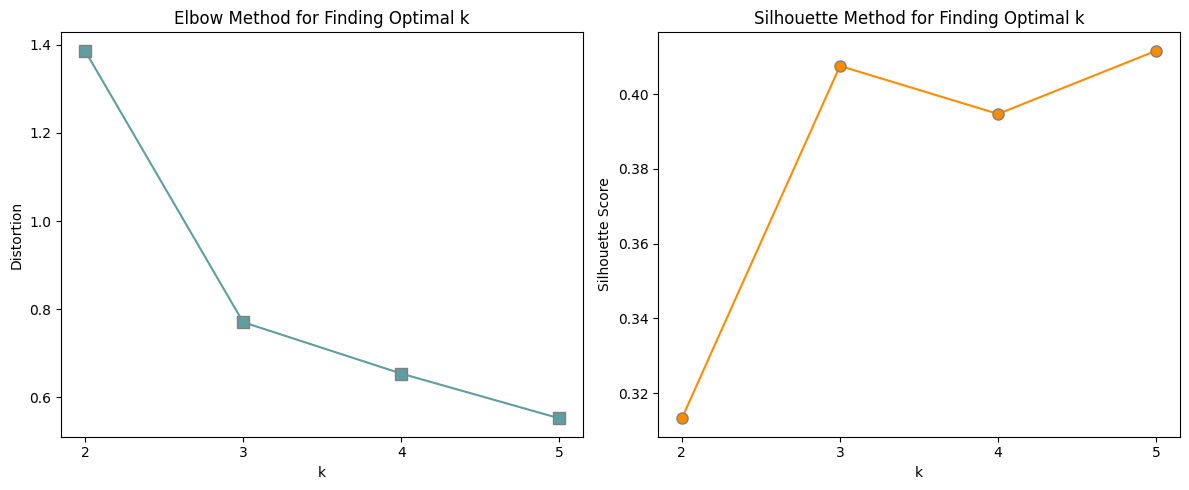

Optimal k according to Elbow method: 2
Optimal k according to Silhouette method: 5


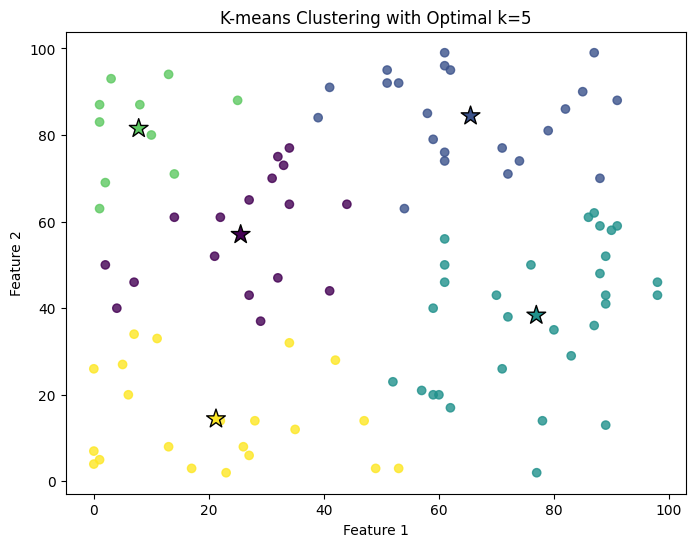

In [10]:

from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def silhouette_coefficient(X, clusters, n_clusters):
    """
    Calculate silhouette coefficient for clustering results

    Parameters:
    -----------
    X : numpy array
        The dataset used for clustering
    clusters : numpy array
        The cluster assignments for each data point
    n_clusters : int
        Number of clusters

    Returns:
    --------
    float
        Average silhouette coefficient
    """
    if n_clusters <= 1 or n_clusters >= len(X):
        return 0  # Invalid number of clusters for silhouette

    try:
        return silhouette_score(X, clusters)
    except:

        return 0


def evaluate_kmeans(X, k_range=range(2, 11), max_iterations=100, random_state=42):
    """
    Evaluate KMeans clustering for different values of k using
    the Elbow method (distortion) and Silhouette method

    Parameters:
    -----------
    X : numpy array
        The dataset to cluster
    k_range : range
        Range of k values to test
    max_iterations : int
        Maximum number of iterations for K-means
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    tuple
        (distortions, silhouette_scores)
    """

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    distortions = []
    silhouette_scores = []

    for k in k_range:
        # Create and fit K-means model
        kmeans = KMeansClustering(k=k)
        labels = kmeans.fit(X_scaled, max_iterations)

        # Calculate distortion (average distance to closest centroid)
        distances = []
        for i, point in enumerate(X_scaled):
            cluster_idx = labels[i]
            centroid = kmeans.centroids[cluster_idx]
            distance = np.sqrt(np.sum((point - centroid)**2))
            distances.append(distance)

        distortion = np.mean(distances)
        distortions.append(distortion)

        # Calculate silhouette score
        if k > 1:  # Silhouette requires at least 2 clusters
            sil_score = silhouette_coefficient(X_scaled, labels, k)
            silhouette_scores.append(sil_score)
        else:
            silhouette_scores.append(0)

        print(f"For k={k}\tAvg. Sil. Coef: {silhouette_scores[-1]:.4f}\tDistortion: {distortion:.4f}")

    return distortions, silhouette_scores


def plot_evaluation_metrics(k_range, distortions, silhouette_scores):
    """
    Plot the evaluation metrics for K-means

    Parameters:
    -----------
    k_range : list or range
        The range of k values tested
    distortions : list
        Distortion values for each k
    silhouette_scores : list
        Silhouette scores for each k
    """
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot the Elbow method
    ax1.plot(k_range, distortions, 's-', markersize=8, color='cadetblue', mec='gray')
    ax1.set_xlabel('k')
    ax1.set_xticks(k_range)
    ax1.set_ylabel('Distortion')
    ax1.set_title('Elbow Method for Finding Optimal k')

    # Plot the Silhouette method
    ax2.plot(k_range, silhouette_scores, 'o-', markersize=8, color='darkorange', mec='gray')
    ax2.set_xlabel('k')
    ax2.set_xticks(k_range)
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Method for Finding Optimal k')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    np.random.seed(42)
    random_points = np.random.randint(0, 100, (100, 2))

    # Evaluate K-means for different k values
    k_range = range(2, 6)
    distortions, silhouette_scores = evaluate_kmeans(random_points, k_range)

    # Plot the results
    plot_evaluation_metrics(k_range, distortions, silhouette_scores)

    # Find the optimal k
    optimal_k_elbow = k_range[np.argmin(np.diff(distortions))]
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    print(f"Optimal k according to Elbow method: {optimal_k_elbow}")
    print(f"Optimal k according to Silhouette method: {optimal_k_silhouette}")

    # Run and visualize K-means with the optimal k
    kmeans = KMeansClustering(k=optimal_k_silhouette)
    labels = kmeans.fit(random_points, max_iterations=100)

    plt.figure(figsize=(8, 6))
    plt.scatter(random_points[:, 0], random_points[:, 1], c=labels, cmap='viridis', alpha=0.8)
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
               c=range(len(kmeans.centroids)), marker='*', s=200, edgecolor='black')
    plt.title(f'K-means Clustering with Optimal k={optimal_k_silhouette}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()